In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import create_df_runs, apply_presentation_theme
from matplotlib.container import BarContainer
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [2]:
#df_runs = create_df_runs()
df_runs = create_df_runs(hypothesis_to_filter="indeterminacy_concat_cases_reruns")

df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,22,22,2026-05-18T11:28:06.423747__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,759efcde,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
1,31,31,2026-05-18T12:00:40.293660__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,759efcde,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
2,46,46,2026-05-15T16:38:33.440343__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
3,55,56,2026-05-15T16:24:28.072343__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort
4,59,60,2026-05-15T15:14:48.442070__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,c85e5338,indeterminacy_concat_cases_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,Accuracy-ChildBenefit-indeterminacy-v3.md,Combined indeterminacy cohort,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-inde...",v3,claude-sonnet-4-5 | Combined indeterminacy cohort


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-indeterminacy-v3.md, False)",6


In [3]:
df_runs.columns

Index(['level_0', 'index', 'run_name', 'model', 'prompt', 'url_allowed',
       'commit', 'hypothesis_name', 'results', 'prompt_name', 'prompt_type',
       'model_name', 'config_key', 'prompt_version', 'config_label'],
      dtype='object')

In [40]:
def build_case_reliability_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Build a pass/fail matrix for one configuration across multiple runs.

    Rows = case IDs
    Columns = run names
    Values = boolean pass/fail
    """
    expected = []
    actual = []

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            #if case_id not in expected:
            #    expected[case_id] = {}
            #if case_id not in actual:
            #    actual[case_id] = {}
            #records[case_id][run_name] = case_data.get("child_evaluations", [])
            #records[case_id][run_name] = [(child["expected_eligible"], child["actual_eligible"]) for child in case_data.get("child_evaluations", []).values()]

            #actual[case_id][run_name] = [child["actual_eligible"] for child in case_data.get("child_evaluations", []).values()]
            #expected[case_id][run_name] = [child["expected_eligible"] for child in case_data.get("child_evaluations", []).values()]

            actual.extend([[case_id, run_name, child_name, child["actual_eligible"]] for child_name, child in case_data.get("child_evaluations", []).items()])
            expected.extend([[case_id, run_name, child_name, child["expected_eligible"]] for child_name, child in case_data.get("child_evaluations", []).items()])

    #df_matrix = pd.DataFrame.from_dict(records, orient="index")
    actual_df = pd.DataFrame.from_records(
        actual, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    expected_df = pd.DataFrame.from_records(
        expected, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    # See "analysis/testOutputs/child_benefit/2026-05-18T12:14:53.570138__Model=claude-sonnet-4-5__Commit=759efcde/concatenated_test_uncertainty_cases/Permutation_RND_SET_2_014.conversation.json"
    # for an example of where for some reason the agent has used the value of the enumeration rather than the key
    actual_df["Eligibility"] = actual_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]
    expected_df["Eligibility"] = expected_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]

    
    actual_df["Eligibility"] = actual_df["Eligibility"].astype("category")
    expected_df["Eligibility"] = expected_df["Eligibility"].astype("category")

    return actual_df, expected_df


In [41]:
actual, expected = build_case_reliability_matrix(df_runs)


In [56]:
actual["Eligibility"].value_counts()

Eligibility
ELIGIBLE         814
INELIGIBLE       543
INDETERMINATE    388
Name: count, dtype: int64

In [57]:
expected["Eligibility"].value_counts()

Eligibility
INDETERMINATE    648
INELIGIBLE       552
ELIGIBLE         545
Name: count, dtype: int64

In [60]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_actual = le.fit_transform(actual.dropna())
le_expected = le.fit_transform(expected.dropna())

/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/tobe/Src/MadeTech/GDS/gds-eligibility-agentic-backend/analysis/.direnv/python-3.14/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [61]:
le.classes_

array(['ELIGIBLE', 'INDETERMINATE', 'INELIGIBLE'], dtype=object)

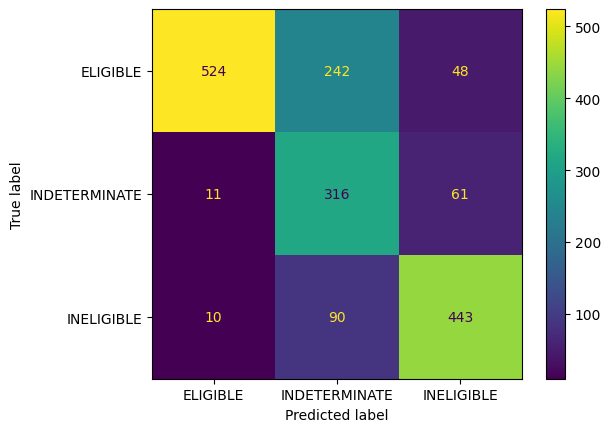

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true=le_actual,
    y_pred=le_expected, 
    #labels=le.classes_
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
